##Система автоматической сегментации и профилирования клиентов

1. Постановка бизнес-задачи

Цель проекта: Переход от массовых маркетинговых коммуникаций к персонализированным стратегиям для снижения издержек и увеличения LTV.

Проблема: В условиях отсутствия ручной разметки клиентской базы компания несет высокие затраты на нерелевантные промо-акции.

Решение: Разработка инструмента, который на основе транзакционного поведения выделяет устойчивые потребительские кластеры и позволяет в режиме реального времени классифицировать новых пользователей для назначения оптимального оффера.

2. Описание данных и подготовка

Источник: Для исследования использован массив деперсонализированных транзакционных данных  реальных данных крупной российской торговой сети в сегменте продуктов питания.

Обеспечение конфиденциальности:
Данные полностью анонимизированы (удалены персональные данные, зашифрованы id).
К финансовым показателям применен метод масштабирования с использованием коэффициентов и зашумления для защиты коммерческой тайны при сохранении математических закономерностей и статистических распределений.

Объем выборки:
 4.2 млн транзакций.

Итоговый аналитический датасет: ~10 700 уникальных клиентов и 38 синтетических признаков (Feature Engineering).

3. Ключевые метрики проекта

Техническая метрика:
F1-score (Macro) = 0.95 на отложенной тестовой выборке. Высокий показатель подтверждает математическую устойчивость выделенных сегментов и их отличную разделимость в пространстве признаков.
Бизнес-метрика:
Прогнозный чистый Uplift прибыли: ~17,9 млн руб./год на анализируемую базу (при расчете маржинальности 25%).

ROI маркетинговых кампаний: Ожидаемый рост эффективности за счет снижения «спам-рассылок» и попадания в целевую потребность клиента.
Так же снижения оттока среди лояльных клиентов


In [ ]:
!pip install catboost

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
)
import warnings

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
plt.style.use("ggplot")
np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.float_format', '{:.4f}'.format)
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/trans_anonymized.csv')

In [ ]:
df.head(10)

,user_id,check_id,check_dttm,purchase_hour,time_of_day,purchase_type,category_name,amount
0,0,0,2025-11-01 00:00:10,0,night,online,Мировые бренды,108.2623
1,0,0,2025-11-01 00:00:10,0,night,online,Мировые бренды,108.2001
2,0,0,2025-11-01 00:00:10,0,night,online,Мировые бренды,110.0476
3,0,0,2025-11-01 00:00:10,0,night,online,Мировые бренды,108.6236
4,0,0,2025-11-01 00:00:10,0,night,online,Мировые бренды,108.4737
5,0,0,2025-11-01 00:00:10,0,night,online,Мировые бренды,109.7743
6,0,0,2025-11-01 00:00:10,0,night,online,Мировые бренды,109.8002
7,0,0,2025-11-01 00:00:10,0,night,online,Мировые бренды,109.6885
8,0,0,2025-11-01 00:00:10,0,night,online,Мировые бренды,109.8051
9,0,0,2025-11-01 00:00:10,0,night,online,Мировые бренды,109.7430


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4166374 entries, 0 to 4166373
Data columns (total 8 columns):
 #   Column         Dtype  
---  ------         -----  
 0   user_id        int64  
 1   check_id       int64  
 2   check_dttm     object 
 3   purchase_hour  int64  
 4   time_of_day    object 
 5   purchase_type  object 
 6   category_name  object 
 7   amount         float64
dtypes: float64(1), int64(3), object(4)
memory usage: 254.3+ MB


In [ ]:
df.groupby('category_name')['user_id'].count()

,user_id
category_name,
Алкоголь,32167
Бакалея,164259
Дача Сад Огород,73
Детское,29911
Замороженные п/ф,64930
Индилавка,1258
Консервация,53939
Кулинария,510640
Микромаркет,880


##Feature engineering

In [ ]:
df['check_dttm'] = pd.to_datetime(df['check_dttm'])

In [ ]:
# агрегация по времени
# средний час
time_agg = df.groupby('user_id')['purchase_hour'].mean().reset_index()
time_agg.columns = ['user_id', 'avg_hour']

# Доли времени суток
time_dist = pd.crosstab(df['user_id'], df['time_of_day'], normalize='index').reset_index()
time_dist.columns = ['user_id'] + [f'pct_{c}' for c in time_dist.columns if c != 'user_id']

In [ ]:
# агрегация по типу покупки (онлайн, оффлайн)
type_dist = pd.crosstab(df['user_id'], df['purchase_type'], normalize='index').reset_index()
type_dist.columns = ['user_id'] + [f'pct_{c}' for c in type_dist.columns if c != 'user_id']

In [ ]:
#  RFM метрики

last_date = df['check_dttm'].max()

rfm = df.groupby('user_id').agg({
    'check_id': 'nunique',
    'amount': 'sum',
    'check_dttm': lambda x: (last_date - x.max()).days
}).reset_index()

rfm.columns = ['user_id', 'num_checks', 'total_spent', 'days_since_last']
#ср чек
rfm['avg_check'] = rfm['total_spent'] / rfm['num_checks']

In [ ]:
# разнообразие корзины
diversity = df.groupby('user_id')['category_name'].nunique().reset_index()
diversity.columns = ['user_id', 'unique_categories']

In [ ]:

# доли категорий
cats = df.pivot_table(index='user_id', columns='category_name', values='amount', aggfunc='sum').fillna(0)
# Нормируем на 100%
cats = cats.div(cats.sum(axis=1), axis=0)
cats.columns = [f'share_{c}' for c in cats.columns]
cats = cats.reset_index()

In [ ]:
# мерж финальной таблицы
final_df = rfm \
    .merge(time_agg, on='user_id', how='left') \
    .merge(time_dist, on='user_id', how='left') \
    .merge(type_dist, on='user_id', how='left') \
    .merge(diversity, on='user_id', how='left') \
    .merge(cats, on='user_id', how='left') \
    .fillna(0)

print("Готово. Размер:", final_df.shape)
final_df.head()

Готово. Размер: (10822, 40)


,user_id,num_checks,total_spent,days_since_last,avg_check,avg_hour,pct_afternoon,pct_evening,pct_morning,pct_night,...,share_Партнерские товары,share_Пекарня,share_Проекты (РНД),share_Проекты нон-фуд,share_Рационы,share_Рыба. Морепродукты,share_Сладости и Торты,"share_Сухофрукты. Сушеные грибы, ягоды. Орехи",share_Сыры,share_Хлеб
0,0,71,133294.1128,47,1877.3819,12.4367,0.2271,0.3057,0.1572,0.3100,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0805,0.0592,0.0023,0.0025
1,1,495,436572.7905,0,881.9652,16.0710,0.3677,0.4633,0.0405,0.1285,...,0.0192,0.0102,0.0000,0.0000,0.0000,0.0948,0.0266,0.0063,0.0674,0.0090
2,2,305,501488.1722,0,1644.2235,12.0142,0.4097,0.1462,0.3014,0.1427,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0468,0.1011,0.0008,0.0059,0.0347
3,3,37,110207.1518,9,2978.5717,15.7471,0.2623,0.5410,0.0937,0.1030,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0554,0.1031,0.0104,0.0054,0.0057
4,4,59,4369.4103,42,74.0578,7.0654,0.0561,0.1308,0.0654,0.7477,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2350


Исходные транзакционные данные были преобразованы в 38 синтетических признаков, включая RFM метрики, доли покупок по 25 категориям товаров и предпочтения по времени суток. Именно сочетание продуктовой корзины и времени визита стало фундаментом для качественного разделения клиентов

##Предобработка и очистка данных


In [ ]:
# класс предобработки данных
# удаляем категорию без клиетнтов
# удаляем клиентов с суммой 0 руб
# убираем аномалии по частоте (99 перцентиль)
class DataPreprocessor:
      """
    Класс для автоматизации предобработки транзакционных данных
    Выполняет:
    1. Удаление неинформативных категорий.
    2. Фильтрацию клиентов с нулевой активностью.
    3. Отсечение аномалий по 99-му перцентилю (на основе обучающей выборки)
    """
  def __init__(self):
    self.q99 = None

  def fit(self, df):
    self.q99 = df['num_checks'].quantile(0.99)
    return self

  def transform(self, df):
    df_copy = df.copy()
    if 'share_Проекты (РНД)' in df_copy.columns:
      df_copy = df_copy.drop(columns=['share_Проекты (РНД)'])
    df_copy = df_copy[df_copy['total_spent'] > 0]
    if self.q99 is not None:
      df_coly = df_copy[df_copy['num_checks'] <= self.q99]
    return df_copy

In [ ]:
# удаляем категорию без клиетнтов
# col_to_drop = 'share_Проекты (РНД)'
# if col_to_drop in final_df.columns:
#     final_df = final_df.drop(columns=[col_to_drop])

In [ ]:
# удаляем клиентов с суммой 0 руб
# zeros_count = final_df[final_df['total_spent'] == 0].shape[0]

# if zeros_count > 0:
#     final_df = final_df[final_df['total_spent'] > 0]

In [ ]:
#убираем аномалии по частоте (99 перцентиль)
# q99 = final_df['num_checks'].quantile(0.99)
# print(f"\n99-й перцентиль по количеству чеков: {q99:.0f}")

# outliers = final_df[final_df['num_checks'] > q99]
# print(f"Будет удалено {outliers.shape[0]}")
# print("Примеры:")
# print(outliers[['user_id', 'num_checks', 'total_spent']].head())




99-й перцентиль по количеству чеков: 427
Будет удалено 108
Примеры:
    user_id  num_checks  total_spent
1         1         495  436572.7905
11       11         940 1156516.8883
13       13         604  718788.8826
14       14         552  403140.8352
16       16         567  984966.8700


In [ ]:
#Оставляем только <= 99%
# final_df = final_df[final_df['num_checks'] <= q99]

# print(final_df.shape)

(10712, 39)


 В ходе анализа выявлено 108 аномальных покупателей (99 перцентиль по частоте) и клиенты с нулевым чеком. Их исключение позволило очистить выборку от шума и сосредоточиться на поведении типичных розничных покупателей. Это критически важно для того, чтобы кластеры получились устойчивыми и интерпретируемыми

##EDA

In [ ]:
final_df.describe()

,user_id,num_checks,total_spent,days_since_last,avg_check,avg_hour,pct_afternoon,pct_evening,pct_morning,pct_night,...,share_Овощи. Фрукты. Грибы. Зелень,share_Партнерские товары,share_Пекарня,share_Проекты нон-фуд,share_Рационы,share_Рыба. Морепродукты,share_Сладости и Торты,"share_Сухофрукты. Сушеные грибы, ягоды. Орехи",share_Сыры,share_Хлеб
count,10712.0000,10712.0000,10712.0000,10712.0000,10712.0000,10712.0000,10712.0000,10712.0000,10712.0000,10712.0000,...,10712.0000,10712.0000,10712.0000,10712.0000,10712.0000,10712.0000,10712.0000,10712.0000,10712.0000,10712.0000
mean,5451.0878,65.4672,85003.7148,20.8378,1269.5793,14.8354,0.4561,0.3101,0.2080,0.0257,...,0.1241,0.0015,0.0021,0.0000,0.0001,0.0369,0.1265,0.0092,0.0291,0.0437
std,3110.5250,70.4127,120261.8349,40.1257,984.8548,2.2575,0.2116,0.2203,0.1953,0.0833,...,0.1223,0.0122,0.0096,0.0005,0.0097,0.0612,0.1313,0.0271,0.0480,0.0572
min,0.0000,10.0000,2.5168,0.0000,0.1198,1.2617,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,2768.7500,18.0000,16590.6873,1.0000,653.7202,13.4669,0.3056,0.1343,0.0567,0.0000,...,0.0357,0.0000,0.0000,0.0000,0.0000,0.0000,0.0412,0.0000,0.0000,0.0119
50%,5462.5000,38.0000,39621.9590,5.0000,999.9619,14.9941,0.4430,0.2821,0.1569,0.0000,...,0.0951,0.0000,0.0000,0.0000,0.0000,0.0153,0.0895,0.0000,0.0137,0.0284
75%,8142.2500,84.0000,102601.4786,20.0000,1562.0620,16.4211,0.5970,0.4520,0.3058,0.0021,...,0.1730,0.0000,0.0000,0.0000,0.0000,0.0489,0.1657,0.0085,0.0391,0.0552
max,10821.0000,427.0000,1650399.3778,329.0000,10108.9260,21.6383,1.0000,1.0000,1.0000,1.0000,...,1.0000,0.4128,0.2758,0.0437,0.9269,0.9684,1.0000,0.9482,1.0000,1.0000


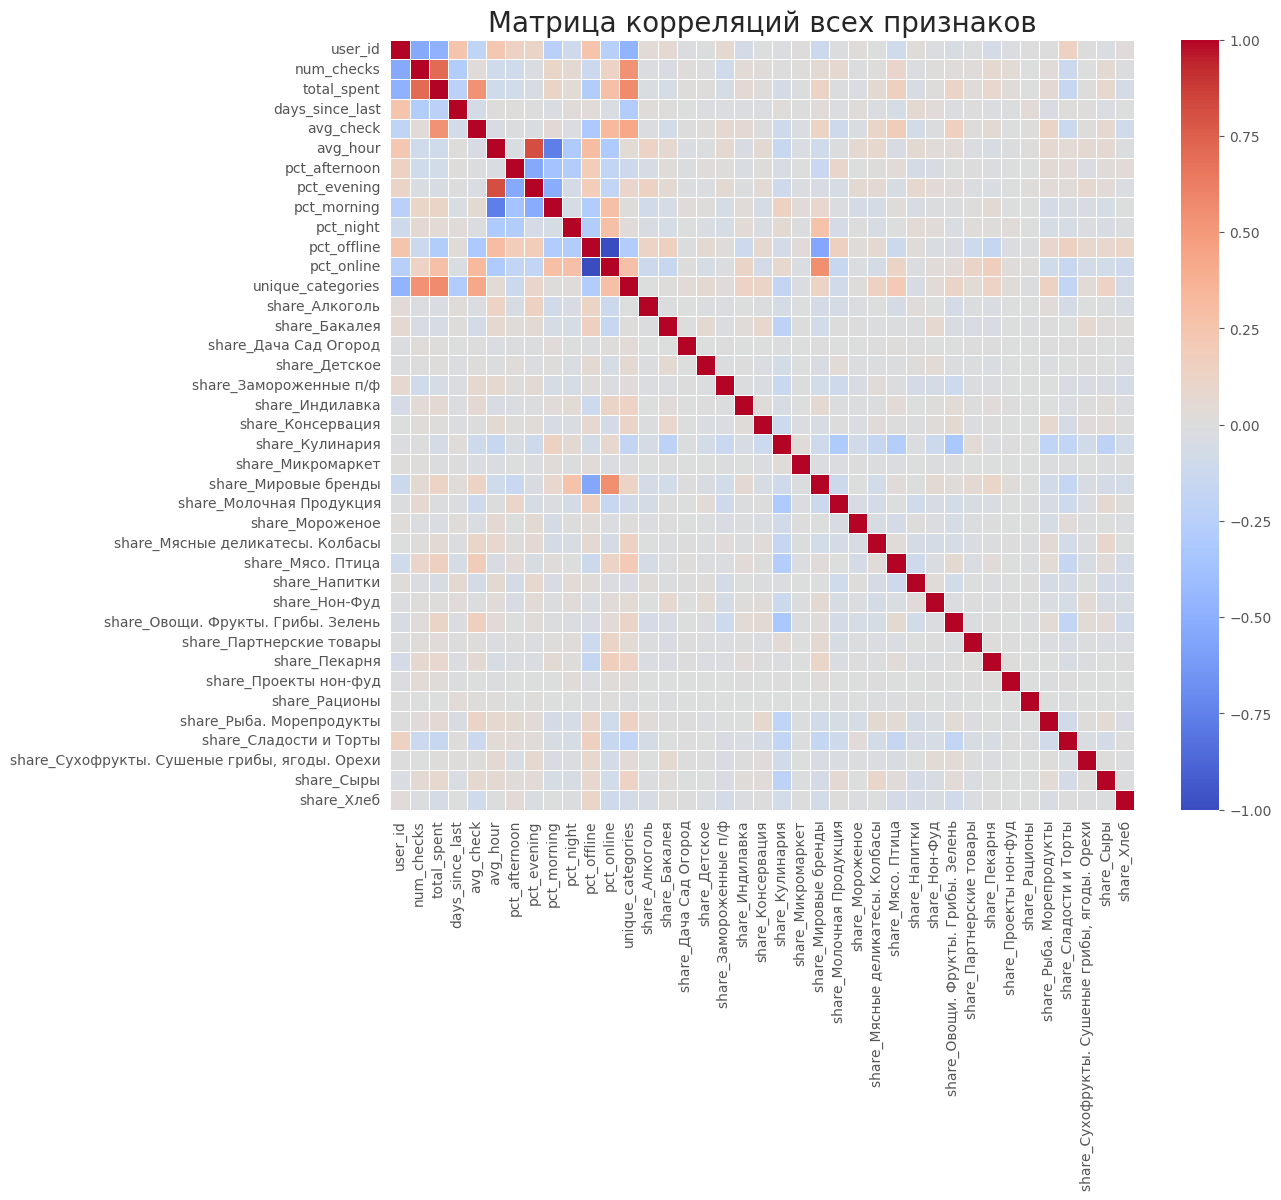

In [ ]:
plt.figure(figsize=(12, 10))

# Считаем корреляцию
corr = final_df.corr()

# Рисуем тепловую карту
# annot=False (не пишем цифры в каждой клетке, иначе будет грязь)
# cmap='coolwarm' (Красное = прямая связь, Синее = обратная)
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, linewidths=0.5)

plt.title('Матрица корреляций всех признаков', fontsize=20)
plt.show()

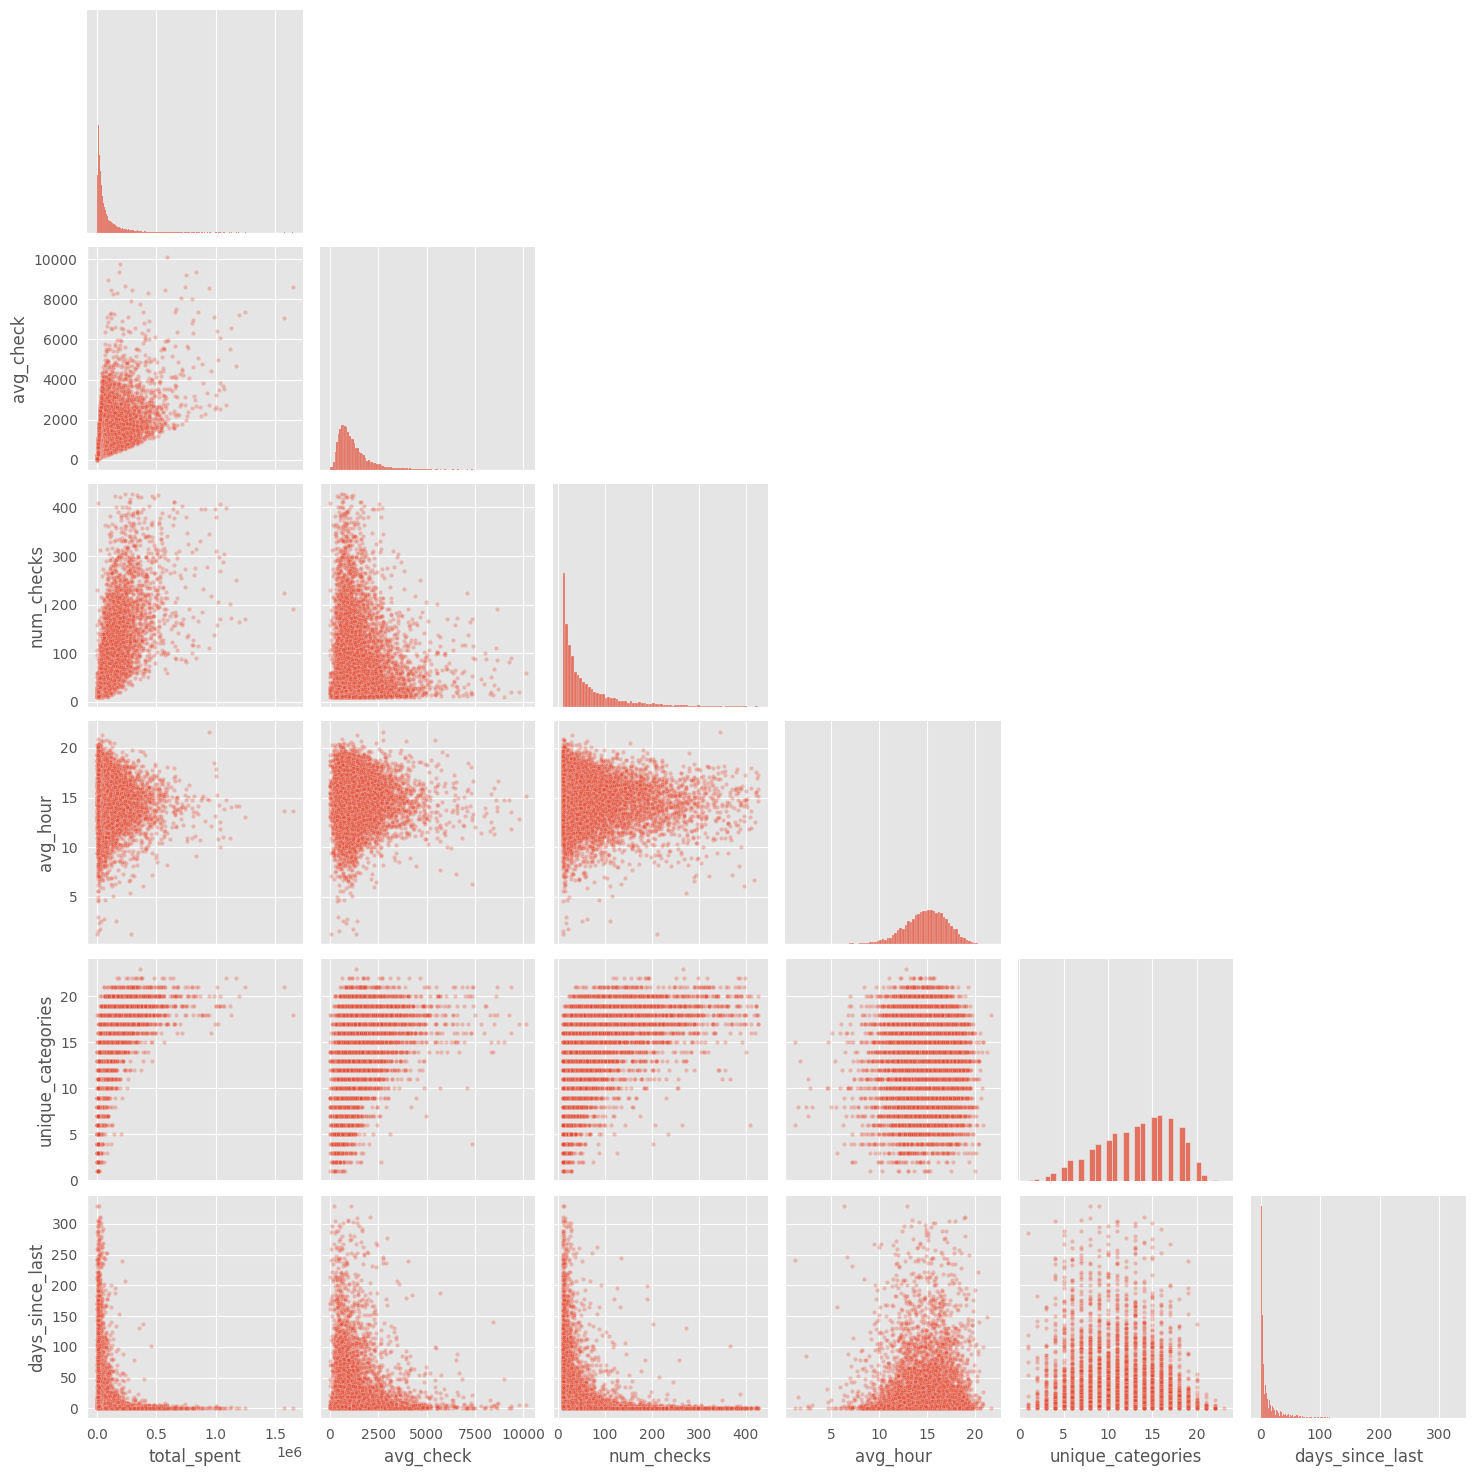

In [ ]:
# Выбирем только главные бизнес-метрики
cols_to_plot = [
    'total_spent',
    'avg_check',
    'num_checks',
    'avg_hour',
    'unique_categories',
    'days_since_last'
]

sns.pairplot(final_df[cols_to_plot], corner=True, plot_kws={'alpha': 0.3, 's': 10})

plt.show()

In [ ]:
cols_to_drop = ['user_id']

X = final_df.drop(columns=cols_to_drop, errors='ignore')

In [ ]:
# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#Запускаем Isolation Forest что бы очистить от аномалий во всех разрезах
# contamination=0.005 (0.5%)
iso = IsolationForest(contamination=0.002, random_state=42, n_jobs=-1)
y_outliers = iso.fit_predict(X_scaled)

#дбавляем метку в датафрейм (временно)
# 1 = норма, -1 = выброс
final_df['is_outlier'] = y_outliers

outliers = final_df[final_df['is_outlier'] == -1]
print(f"Всего выбросов найдено: {len(outliers)} (из {len(final_df)})")

sort_col = 'total_spent' if 'total_spent' in final_df.columns else 'num_checks'

print("Примеры удаляемых (Топ-5 самых дорогих/активных):")
display(outliers.sort_values(by=sort_col, ascending=False).head(5))

Всего выбросов найдено: 22 (из 10712)
Примеры удаляемых (Топ-5 самых дорогих/активных):


,user_id,num_checks,total_spent,days_since_last,avg_check,avg_hour,pct_afternoon,pct_evening,pct_morning,pct_night,...,share_Партнерские товары,share_Пекарня,share_Проекты нон-фуд,share_Рационы,share_Рыба. Морепродукты,share_Сладости и Торты,"share_Сухофрукты. Сушеные грибы, ягоды. Орехи",share_Сыры,share_Хлеб,is_outlier
347,347,345,946588.9024,0,2743.7359,21.6383,0.0110,0.1341,0.0037,0.8512,...,0.0000,0.0000,0.0000,0.0000,0.0358,0.0561,0.0330,0.0623,0.0201,-1
305,305,276,821193.7789,0,2975.3398,11.1457,0.1922,0.2800,0.1071,0.4207,...,0.0000,0.0000,0.0000,0.0000,0.0170,0.1148,0.0095,0.0477,0.0593,-1
64,64,397,388080.8521,0,977.5336,6.0411,0.1285,0.0389,0.2188,0.6138,...,0.0000,0.0064,0.0000,0.0000,0.2220,0.1122,0.0026,0.0139,0.0122,-1
593,593,254,180917.9962,0,712.2756,10.3141,0.0919,0.3378,0.0252,0.5452,...,0.0000,0.0000,0.0000,0.0000,0.0084,0.2040,0.1902,0.0212,0.1094,-1
1730,1730,16,117238.5770,22,7327.4111,6.2900,0.0000,0.0000,0.2873,0.7127,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-1


In [ ]:
#фильтр
final_df_clean = final_df[final_df['is_outlier'] != -1].copy()
# удаляем временную метку
final_df_clean.drop(columns=['is_outlier'], inplace=True)


In [ ]:
# удалим все лишнее, если осталось от предыдущих запусков
cols_cleanup = ['cluster', 'cluster_8', 'segment', 'sub_cluster', 'x', 'y', 'x_8', 'y_8', 'is_outlier']
existing = [c for c in cols_cleanup if c in final_df_clean.columns]
df_source = final_df_clean.drop(columns=existing)

# делим сразу 80% на обучение, 20% тест
df_train, df_test = train_test_split(df_source, test_size=0.2, random_state=42)

In [ ]:
preprocessor = DataPreprocessor()

In [ ]:
preprocessor.fit(X_train)

In [ ]:
X_train = preprocessor.transform(X_train)
X_test = preprocessor.transform(X_test)

In [ ]:
# Проверка репрезентативности
# Сравниваем средние значения ключевых метрик
check_metrics = pd.DataFrame({
    'Train_Mean': df_train[['total_spent', 'avg_check', 'num_checks']].mean(),
    'Test_Mean':  df_test[['total_spent', 'avg_check', 'num_checks']].mean()
})

# Считаем разницу
check_metrics['Diff_%'] = ((check_metrics['Train_Mean'] - check_metrics['Test_Mean']) / check_metrics['Train_Mean'] * 100).abs()

display(check_metrics.round(1))

if check_metrics['Diff_%'].max() < 5:
    print("Различия между Train и Test менее 5%")
else:
    print("Есть перекосы")

,Train_Mean,Test_Mean,Diff_%
total_spent,84874.2000,85136.8000,0.3000
avg_check,1267.3000,1279.2000,0.9000
num_checks,65.7000,64.6000,1.7000


Различия между Train и Test менее 5%


In [ ]:
# дропаем денежные признаки
cols_money = ['user_id', 'total_spent', 'avg_check', 'amount', 'num_checks']
X_train_km = df_train.drop(columns=cols_money, errors='ignore')
X_test_km  = df_test.drop(columns=cols_money, errors='ignore')

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_km)
X_test_scaled  = scaler.transform(X_test_km)

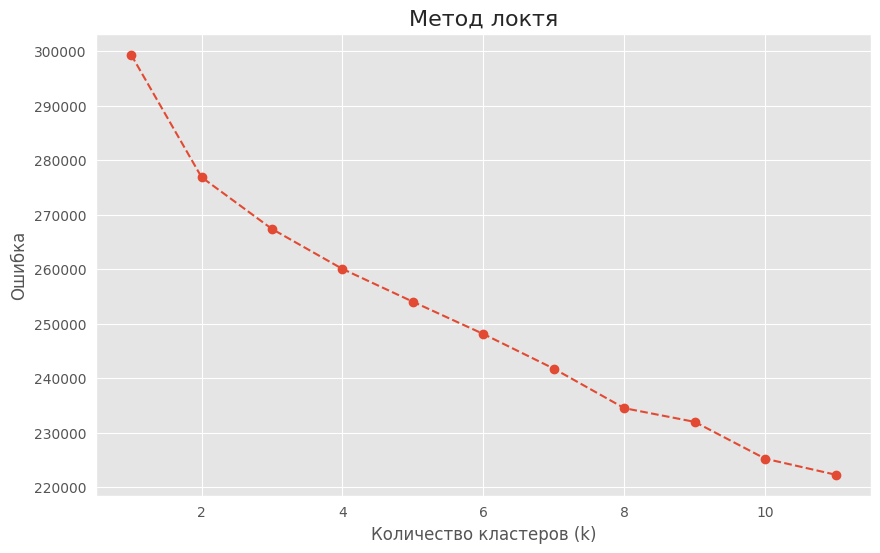

In [ ]:
# метод локтя
# строим графики для k от 1 до 10 кластеров
inertia = []
K_range = range(1, 12)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertia.append(kmeans.inertia_)

#графики
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Метод локтя', fontsize=16)
plt.xlabel('Количество кластеров (k)', fontsize=12)
plt.ylabel('Ошибка', fontsize=12)
plt.grid(True)
plt.show()

График локтя показывает существенное снижение инерции до 3-4 кластеров. Однако, для решения бизнес-задачи (персонализация предложений) более глубокая сегментация (k=4 и k=8) дает экономически более значимые результаты, позволяя выделить узкие целевые группы (например, 'Семьи с детьми'), которые теряются при грубом делении на 3 части

##Кластеризация

In [ ]:
# 4 Обучаем K-Means (4 кластера) НА TRAIN
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_train_scaled) # Учимся только на трейне!

# 2. Присваиваем метки ОБЕИМ выборкам
df_train['cluster'] = kmeans.labels_
df_test['cluster'] = kmeans.predict(X_test_scaled) # Тест размечаем по правилам трейна

# 3. Объединяем их обратно, чтобы построить КРАСИВЫЙ ОТЧЕТ ПО ВСЕМ ЛЮДЯМ
# (Это безопасно, так как обучение уже прошло)
df_full_labeled = pd.concat([df_train, df_test])

# 4. Считаем средние профили
profiles = df_full_labeled.groupby('cluster').mean()
n_clusters = df_full_labeled['cluster'].nunique()
print(f"Всего кластеров: {n_clusters}\n")

# выводы
for i in range(n_clusters):
    print(f"\n--- КЛАСТЕР {i} ---")

    # Считаем людей (берем из объединенной базы)
    count = df_full_labeled[df_full_labeled['cluster']==i].shape[0]
    print(f" Людей: {count}")

    # Базовые метрики (с защитой от ошибок, если каких-то колонок нет)
    try:
        if 'avg_check' in profiles.columns:
            print(f" Средний чек: {profiles.loc[i, 'avg_check']:.0f} руб.")
        if 'num_checks' in profiles.columns:
            print(f" Частота: {profiles.loc[i, 'num_checks']:.1f} раз")
        if 'total_spent' in profiles.columns:
            print(f" Всего потратил: {profiles.loc[i, 'total_spent']:.0f} руб.")

        # Если есть колонка про онлайн
        cols_online = [c for c in profiles.columns if 'online' in c.lower()]
        if cols_online:
            col_name = cols_online[0]
            print(f" Онлайн: {profiles.loc[i, col_name]*100:.1f}%")

        if 'avg_hour' in profiles.columns:
             print(f" Час покупки: {profiles.loc[i, 'avg_hour']:.1f} ч.")

    except Exception as e:
        print(f" Ошибка в метриках: {e}")

    # Топ-10 категорий
    share_cols = [c for c in profiles.columns if c.startswith('share_')]

    if share_cols:
        top_cats = profiles.loc[i, share_cols].sort_values(ascending=False).head(10)

        print("\n Что покупают (Топ-10):")
        for cat, val in top_cats.items():
            clean_name = cat.replace('share_', '')
            print(f"   - {clean_name}: {val*100:.1f}%")

    print("-" * 30)

Всего кластеров: 4


--- КЛАСТЕР 0 ---
 Людей: 2744
 Средний чек: 1118 руб.
 Частота: 59.8 раз
 Всего потратил: 64111 руб.
 Онлайн: 14.4%
 Час покупки: 17.1 ч.

 Что покупают (Топ-10):
   - Кулинария: 15.9%
   - Сладости и Торты: 14.0%
   - Овощи. Фрукты. Грибы. Зелень: 12.6%
   - Молочная Продукция: 8.7%
   - Замороженные п/ф: 5.8%
   - Мясные деликатесы. Колбасы: 5.4%
   - Мясо. Птица: 4.9%
   - Рыба. Морепродукты: 4.5%
   - Напитки: 4.4%
   - Бакалея: 4.2%
------------------------------

--- КЛАСТЕР 1 ---
 Людей: 3713
 Средний чек: 1708 руб.
 Частота: 84.2 раз
 Всего потратил: 139915 руб.
 Онлайн: 86.5%
 Час покупки: 14.3 ч.

 Что покупают (Топ-10):
   - Овощи. Фрукты. Грибы. Зелень: 15.3%
   - Кулинария: 12.2%
   - Мировые бренды: 11.1%
   - Сладости и Торты: 9.5%
   - Мясо. Птица: 9.0%
   - Молочная Продукция: 8.7%
   - Замороженные п/ф: 4.7%
   - Мясные деликатесы. Колбасы: 4.3%
   - Хлеб: 3.7%
   - Рыба. Морепродукты: 3.6%
------------------------------

--- КЛАСТЕР 2 ---
 Людей

Визуализация методом главных компонент (PCA) подтверждает наличие 4-х плотных ядер в данных:

VIP/Семья: высокий чек, закупки впрок

Офисники: готовая еда в обеденное время

Холостяки: вечерние покупки «на ужин»

Эконом: базовый набор товаров первой необходимости

Наличие перекрывающихся областей на графике свидетельствует о наличии смешанных типов клиентов (~11% базы)

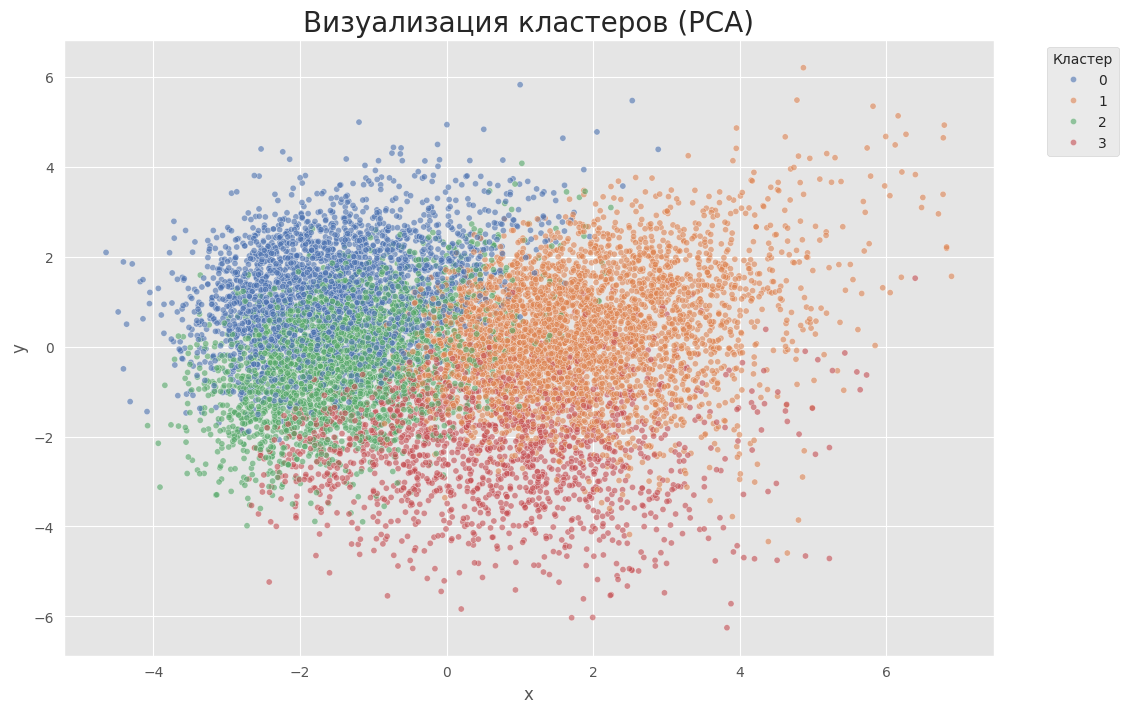

In [ ]:
# визуализация кластеров
cols_for_pca = df_full_labeled.select_dtypes(include='number').columns.drop(['user_id', 'cluster', 'x', 'y'], errors='ignore')
X_viz = df_full_labeled[cols_for_pca].fillna(0)

scaler_viz = StandardScaler()
X_viz_scaled = scaler_viz.fit_transform(X_viz)
#  Сжимаем
pca = PCA(n_components=2)
embedding = pca.fit_transform(X_viz_scaled)

df_full_labeled['x'] = embedding[:, 0]
df_full_labeled['y'] = embedding[:, 1]

# Фильтруем выбросы
df_viz = df_full_labeled[df_full_labeled['x'] < 7]

# график
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_viz,
    x='x',
    y='y',
    hue='cluster',
    palette='deep',
    s=20,
    alpha=0.6
)

plt.title('Визуализация кластеров (PCA)', fontsize=20)
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

"Визуализация PCA в 2D показывает частичное перекрытие кластеров. 1 и 3 кластеры выглядят более разделенно, 0 и 2 довольно сильно перемешаны. Это подтверждает гипотезу о наличии смешанных профилей потребления , где один клиент может проявлять признаки нескольких сегментов

Кластеризация 1 кластера

In [ ]:
# Попробуем разбить Кластер 1 на 3 части

target_cluster_id = 1
subset_vip = df_full_labeled[df_full_labeled['cluster'] == target_cluster_id].copy()

cols_ignore = ['cluster', 'cluster_8', 'segment', 'sub_cluster', 'x', 'y', 'user_id', 'total_spent', 'avg_check', 'amount', 'num_checks']
X_sub = subset_vip.drop(columns=cols_ignore, errors='ignore')

scaler_sub = StandardScaler()
X_sub_scaled = scaler_sub.fit_transform(X_sub)

kmeans_sub = KMeans(n_clusters=3, random_state=42)
subset_vip['sub_cluster'] = kmeans_sub.fit_predict(X_sub_scaled)
sub_n_clusters = 3

sub_profiles = subset_vip.groupby('sub_cluster').mean()

for i in range(sub_n_clusters):
    print(f"\n--- ПОДГРУППА {i} (Внутри VIP) ---")

    count = subset_vip[subset_vip['sub_cluster'] == i].shape[0]
    print(f" Людей: {count} ({count/len(subset_vip)*100:.1f}%)")

    try:
        if 'avg_check' in sub_profiles.columns:
            print(f" Средний чек: {sub_profiles.loc[i, 'avg_check']:.0f} руб.")
        if 'num_checks' in sub_profiles.columns:
            print(f" Частота: {sub_profiles.loc[i, 'num_checks']:.1f} раз")
        if 'total_spent' in sub_profiles.columns:
            print(f" Всего потратил: {sub_profiles.loc[i, 'total_spent']:.0f} руб.")

        cols_online = [c for c in sub_profiles.columns if 'online' in c.lower()]
        if cols_online:
            col_name = cols_online[0]
            print(f" Онлайн: {sub_profiles.loc[i, col_name]*100:.1f}%")

        if 'avg_hour' in sub_profiles.columns:
             print(f" Час покупки: {sub_profiles.loc[i, 'avg_hour']:.1f} ч.")

    except Exception as e:
        print(f" Ошибка в метриках: {e}")

    share_cols = [c for c in sub_profiles.columns if c.startswith('share_')]
    if share_cols:
        top_cats = sub_profiles.loc[i, share_cols].sort_values(ascending=False).head(10)
        print(" Что покупают (Топ-10):")
        for cat, val in top_cats.items():
            clean_name = cat.replace('share_', '')
            print(f"   - {clean_name}: {val*100:.1f}%")

    print("-" * 30)


--- ПОДГРУППА 0 (Внутри VIP) ---
 Людей: 907 (24.4%)
 Средний чек: 1507 руб.
 Частота: 101.8 раз
 Всего потратил: 141796 руб.
 Онлайн: 63.7%
 Час покупки: 14.7 ч.
 Что покупают (Топ-10):
   - Овощи. Фрукты. Грибы. Зелень: 15.1%
   - Кулинария: 12.4%
   - Сладости и Торты: 10.6%
   - Молочная Продукция: 9.4%
   - Мясо. Птица: 9.1%
   - Мировые бренды: 5.9%
   - Замороженные п/ф: 5.1%
   - Мясные деликатесы. Колбасы: 4.5%
   - Бакалея: 4.2%
   - Рыба. Морепродукты: 4.2%
------------------------------

--- ПОДГРУППА 1 (Внутри VIP) ---
 Людей: 1513 (40.8%)
 Средний чек: 1961 руб.
 Частота: 92.7 раз
 Всего потратил: 172899 руб.
 Онлайн: 93.6%
 Час покупки: 12.9 ч.
 Что покупают (Топ-10):
   - Овощи. Фрукты. Грибы. Зелень: 17.2%
   - Мясо. Птица: 11.0%
   - Мировые бренды: 9.9%
   - Молочная Продукция: 9.8%
   - Кулинария: 9.6%
   - Сладости и Торты: 8.5%
   - Мясные деликатесы. Колбасы: 4.7%
   - Замороженные п/ф: 4.7%
   - Рыба. Морепродукты: 4.2%
   - Хлеб: 3.7%
-------------------------

Анализ подгрупп в сегменте VIP / Семья
Даже внутри самого лояльного сегмента есть три разных типа поведения:

Подгруппа 0: "Частые гости" (Офлайн + Онлайн)

Кто это: Самые частые покупатели (101 визит в год!), но с чуть меньшим чеком (1500 руб)

Особенность: Доля онлайна всего 64% (ниже, чем у других VIP). Часто заходят сами.

Корзина: Сбалансированная (Овощи + Кулинария + Сладости)

Подгруппа 1: "Золотые киты" (Супер-VIP)

Кто это: Самый богатый сегмент. Огромный средний чек (1960 руб) и гигантские общие траты (172к руб)

Особенность: Почти 100% онлайн (94%). Закупаются масштабно и часто (92 раза).

Корзина: Много свежих продуктов (Овощи 17%, Мясо 11%) - готовят дома дорогие блюда

Подгруппа 2: "Брендозависимые"

Кто это: Покупают реже всех (62 раза), но тоже онлайн (94%)

Особенность: Самая высокая доля "Мировых брендов" (16%) и "Кулинарии" (15%).

Корзина: Любят дорогие импортные товары и готовую еду. Скорее всего, обеспеченные холостяки или пары без детей


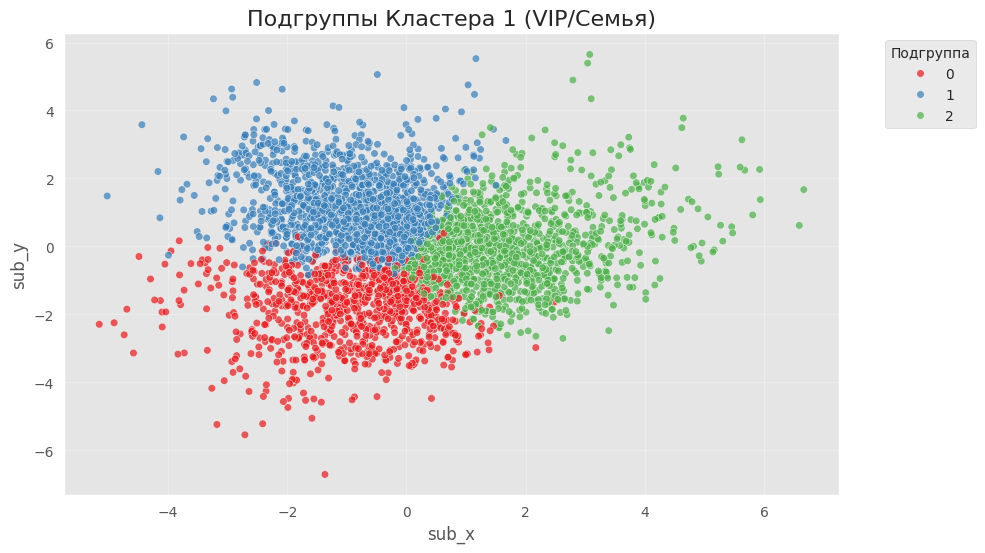

In [ ]:
# PCA
pca_sub = PCA(n_components=2)
embedding_sub = pca_sub.fit_transform(X_sub_scaled)

# Добавляем координаты
subset_vip['sub_x'] = embedding_sub[:, 0]
subset_vip['sub_y'] = embedding_sub[:, 1]

# график
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=subset_vip,
    x='sub_x',
    y='sub_y',
    hue='sub_cluster',
    palette='Set1',
    s=30,
    alpha=0.7
)
plt.title(f'Подгруппы Кластера {target_cluster_id} (VIP/Семья)', fontsize=16)
plt.legend(title='Подгруппа', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

Для подгрупп в кластере VIP, график показывает три четкие области. Можно использовать саб-кластеизацию для персонализации

##Кластеризация с количеством кластеров = 8

In [ ]:
#Обучение (train)
kmeans_8 = KMeans(n_clusters=8, random_state=42)
kmeans_8.fit(X_train_scaled)

# разметка
df_train['cluster_8'] = kmeans_8.labels_
df_test['cluster_8']  = kmeans_8.predict(X_test_scaled)

df_full_8 = pd.concat([df_train, df_test])

# вывод
profiles_8 = df_full_8.groupby('cluster_8').mean()
print(f"Всего кластеров: {profiles_8.shape[0]}\n")

for i in range(8):
    print(f"\n--- КЛАСТЕР {i} ---")

    count = df_full_8[df_full_8['cluster_8']==i].shape[0]
    percent = count / df_full_8.shape[0] * 100
    print(f"Людей: {count} ({percent:.1f}%)")

    if 'avg_check' in profiles_8.columns:
        print(f"Чек: {profiles_8.loc[i, 'avg_check']:.0f} руб.")
    if 'total_spent' in profiles_8.columns:
        print(f"Всего: {profiles_8.loc[i, 'total_spent']:.0f} руб.")
    if 'num_checks' in profiles_8.columns:
        print(f"Частота: {profiles_8.loc[i, 'num_checks']:.1f}")
    if 'avg_hour' in profiles_8.columns:
         print(f"Время: {profiles_8.loc[i, 'avg_hour']:.1f} ч.")
    # ---------------------------

    cols_online = [c for c in profiles_8.columns if 'online' in c.lower()]
    if cols_online:
         print(f"Онлайн: {profiles_8.loc[i, cols_online[0]]*100:.1f}%")

    print("Топ-10 категории:")
    share_cols = [c for c in profiles_8.columns if c.startswith('share_')]
    if len(share_cols) > 0:
        top_cats = profiles_8.loc[i, share_cols].sort_values(ascending=False).head(10)
        for cat, val in top_cats.items():
            print(f"   - {cat.replace('share_', '')}: {val*100:.1f}%")

    print("-" * 30)



Всего кластеров: 8


--- КЛАСТЕР 0 ---
Людей: 2385 (22.3%)
Чек: 1139 руб.
Всего: 70689 руб.
Частота: 64.9
Время: 17.1 ч.
Онлайн: 15.2%
Топ-10 категории:
   - Кулинария: 17.4%
   - Сладости и Торты: 14.5%
   - Овощи. Фрукты. Грибы. Зелень: 11.1%
   - Молочная Продукция: 9.2%
   - Мясные деликатесы. Колбасы: 6.0%
   - Рыба. Морепродукты: 4.8%
   - Напитки: 4.7%
   - Мясо. Птица: 4.6%
   - Бакалея: 4.5%
   - Хлеб: 4.3%
------------------------------

--- КЛАСТЕР 1 ---
Людей: 431 (4.0%)
Чек: 1340 руб.
Всего: 38351 руб.
Частота: 29.8
Время: 15.2 ч.
Онлайн: 39.4%
Топ-10 категории:
   - Замороженные п/ф: 37.4%
   - Сладости и Торты: 11.8%
   - Кулинария: 9.3%
   - Овощи. Фрукты. Грибы. Зелень: 6.8%
   - Молочная Продукция: 5.6%
   - Мясные деликатесы. Колбасы: 4.7%
   - Мясо. Птица: 3.6%
   - Рыба. Морепродукты: 3.3%
   - Хлеб: 3.0%
   - Бакалея: 2.9%
------------------------------

--- КЛАСТЕР 2 ---
Людей: 656 (6.1%)
Чек: 1542 руб.
Всего: 95609 руб.
Частота: 65.7
Время: 14.2 ч.
Онлайн: 57.1%

Увеличение количества кластеров до восьми позволяет выявить узкоспециализированные потребительские профили которые скрыты при более грубой сегментации

Кластер 0: это вечерние покупатели кулинарии и сладостей предпочитающие оффлайн визиты

Кластер 1: выделяется аномально высоким потреблением замороженных полуфабрикатов

Кластер 2: представляет собой онлайн ориентированных закупщиков мяса и птицы с высоким средним чеком

Кластер 3: это фанаты кулинарии совершающие покупки преимущественно онлайн в дневное время

Кластер 4: является самым массовым и лояльным сегментом с максимальными тратами и активным использованием мировых брендов

Кластер 5: это классические оффлайн покупатели базового набора молочной продукции и хлеба

Кластер 6: формирует микрогруппу с фокусом на алкогольную продукцию и вечерние посещения

Кластер 7: объединяет вегетарианцев или любителей здорового питания с акцентом на овощи и фрукты

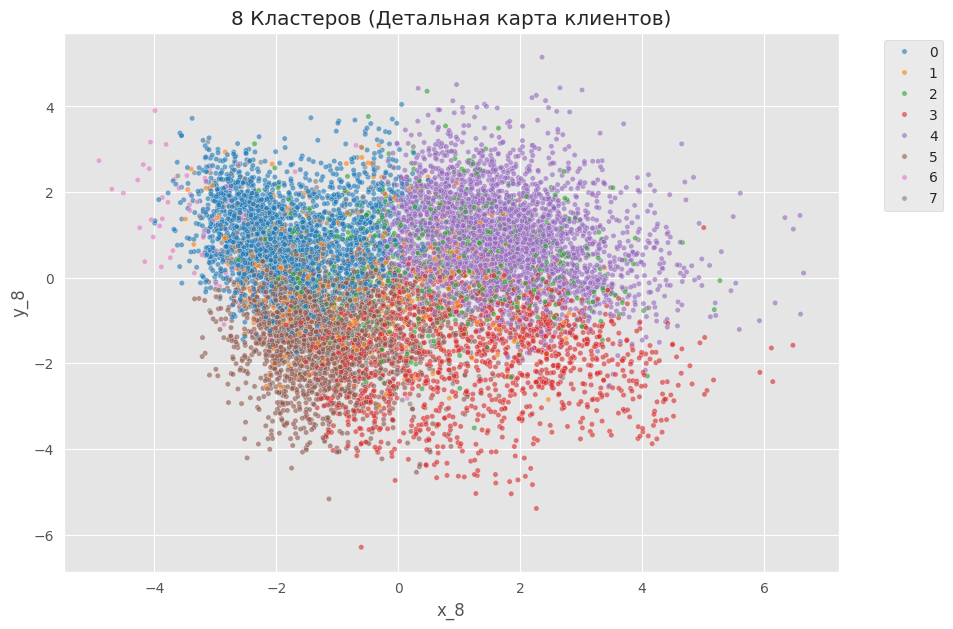

In [ ]:
X_full_scaled = np.vstack([X_train_scaled, X_test_scaled])

#  сжимаем
pca = PCA(n_components=2)
embedding = pca.fit_transform(X_full_scaled)

# добавляем координаты
df_full_8['x_8'] = embedding[:, 0]
df_full_8['y_8'] = embedding[:, 1]

df_full_8 = df_full_8[df_full_8['x_8'] < 7]

# график
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_full_8,
    x='x_8',
    y='y_8',
    hue='cluster_8',
    palette='tab10',
    s=15,
    alpha=0.6
)
plt.title('8 Кластеров (Детальная карта клиентов)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## EDA для классификации

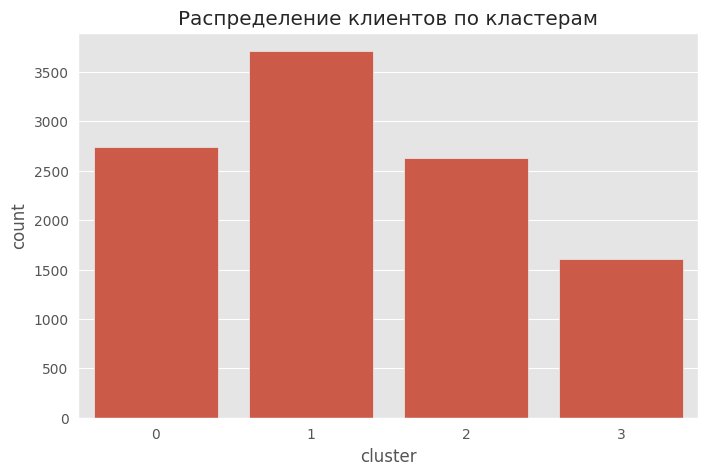

cluster
1   34.7000
0   25.7000
2   24.6000
3   15.0000
Name: proportion, dtype: float64


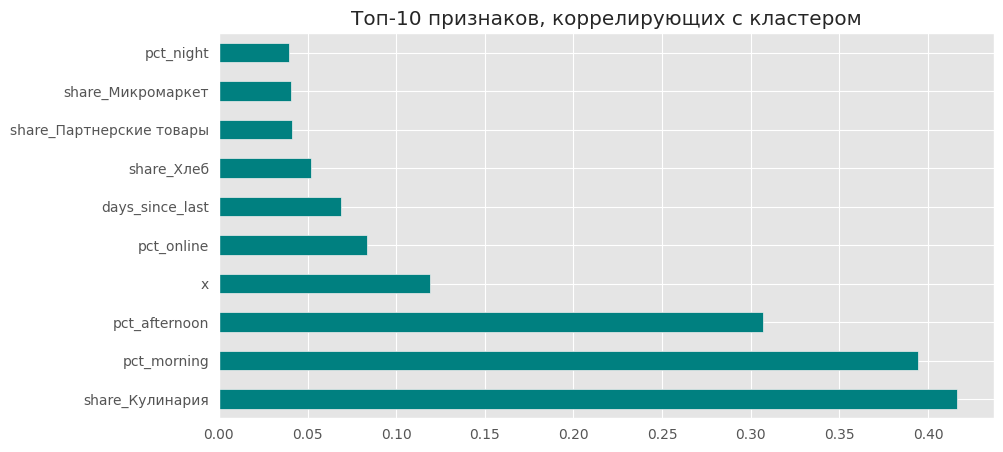

In [ ]:

plt.figure(figsize=(8, 5))
sns.countplot(x='cluster', data=df_full_labeled)
plt.title('Распределение клиентов по кластерам')
plt.show()

print(df_full_labeled['cluster'].value_counts(normalize=True).mul(100).round(1))

# Считаем корреляцию всех признаков с номером кластера
numeric_cols = df_full_labeled.select_dtypes(include=[np.number]).columns
corr_with_target = df_full_labeled[numeric_cols].corr()['cluster'].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
corr_with_target.drop('cluster', errors='ignore').head(10).plot(kind='barh', color='teal')
plt.title('Топ-10 признаков, коррелирующих с кластером')
plt.show()

Есть небольшой дисбаланс в кластерах, попробуем сначала обучить модель без предобработки

## CatBoost  классификация

In [ ]:

# Список того, что нужно убрать
cols_to_drop = [
    'user_id',
    'cluster',
    'cluster_8',
    'segment',
    'sub_cluster',
    'x', 'y', 'x_8', 'y_8',
    'is_outlier'
]

# Создаем X для train и test
X_train_cb = df_train.drop(columns=cols_to_drop, errors='ignore')
X_test_cb  = df_test.drop(columns=cols_to_drop, errors='ignore')

# Создаем y
y_train_cb = df_train['cluster']
y_test_cb  = df_test['cluster']

print(f"Признаки для обучения ({X_train_cb.shape[1]} шт.):\n{list(X_train_cb.columns)}")

Признаки для обучения (38 шт.):
['num_checks', 'total_spent', 'days_since_last', 'avg_check', 'avg_hour', 'pct_afternoon', 'pct_evening', 'pct_morning', 'pct_night', 'pct_offline', 'pct_online', 'unique_categories', 'share_Алкоголь', 'share_Бакалея', 'share_Дача Сад Огород', 'share_Детское', 'share_Замороженные п/ф', 'share_Индилавка', 'share_Консервация', 'share_Кулинария', 'share_Микромаркет', 'share_Мировые бренды', 'share_Молочная Продукция', 'share_Мороженое', 'share_Мясные деликатесы. Колбасы', 'share_Мясо. Птица', 'share_Напитки', 'share_Нон-Фуд', 'share_Овощи. Фрукты. Грибы. Зелень', 'share_Партнерские товары', 'share_Пекарня', 'share_Проекты нон-фуд', 'share_Рационы', 'share_Рыба. Морепродукты', 'share_Сладости и Торты', 'share_Сухофрукты. Сушеные грибы, ягоды. Орехи', 'share_Сыры', 'share_Хлеб']


In [ ]:
# обучение
model_cb = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50
)

model_cb.fit(X_train_cb, y_train_cb, eval_set=(X_test_cb, y_test_cb), plot=False)

0:	learn: 0.8427497	test: 0.8381647	best: 0.8381647 (0)	total: 139ms	remaining: 2m 18s
100:	learn: 0.9270982	test: 0.9181523	best: 0.9181523 (100)	total: 7.11s	remaining: 1m 3s
200:	learn: 0.9524409	test: 0.9390995	best: 0.9390995 (194)	total: 13.3s	remaining: 52.7s
300:	learn: 0.9645276	test: 0.9460947	best: 0.9470320 (294)	total: 17.2s	remaining: 39.9s
400:	learn: 0.9721492	test: 0.9498238	best: 0.9503027 (391)	total: 23.3s	remaining: 34.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9503027052
bestIteration = 391

Shrink model to first 392 iterations.


In [ ]:
#анализ результатов вероятностей
import pandas as pd # На случай если pd не видно

# Используем X_test_cb для предсказаний
probs = model_cb.predict_proba(X_test_cb)

# Создаем датафрейм с результатами (индекс берем из теста)
results_df = pd.DataFrame(probs, columns=[f'Prob_Cluster_{i}' for i in range(4)], index=X_test_cb.index)

# Добавляем правильные ответы и предсказания
results_df['True_Cluster'] = y_test_cb
results_df['Predicted_Cluster'] = model_cb.predict(X_test_cb)

# Считаем уверенность (максимальная вероятность)
prob_cols = [c for c in results_df.columns if 'Prob_' in c]
results_df['Confidence'] = results_df[prob_cols].max(axis=1)

# Ищем "пограничников" (тех, в ком модель сомневается)
uncertain = results_df[results_df['Confidence'] < 0.6].sort_values('Confidence')

print(f"Всего в тесте: {len(results_df)}")
print(f"Сомневающихся (<60%): {len(uncertain)} ({len(uncertain)/len(results_df)*100:.1f}%)")

print(classification_report(y_test_cb, results_df['Predicted_Cluster']))


Всего в тесте: 2138
Сомневающихся (<60%): 110 (5.1%)
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       560
           1       0.95      0.97      0.96       770
           2       0.96      0.93      0.94       501
           3       0.94      0.91      0.92       307

    accuracy                           0.95      2138
   macro avg       0.95      0.94      0.95      2138
weighted avg       0.95      0.95      0.95      2138



Train
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2184
           1       0.97      0.98      0.98      2943
           2       0.97      0.97      0.97      2126
           3       0.97      0.95      0.96      1299

    accuracy                           0.97      8552
   macro avg       0.97      0.97      0.97      8552
weighted avg       0.97      0.97      0.97      8552


Test
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       560
           1       0.95      0.97      0.96       770
           2       0.96      0.93      0.94       501
           3       0.94      0.91      0.92       307

    accuracy                           0.95      2138
   macro avg       0.95      0.94      0.95      2138
weighted avg       0.95      0.95      0.95      2138



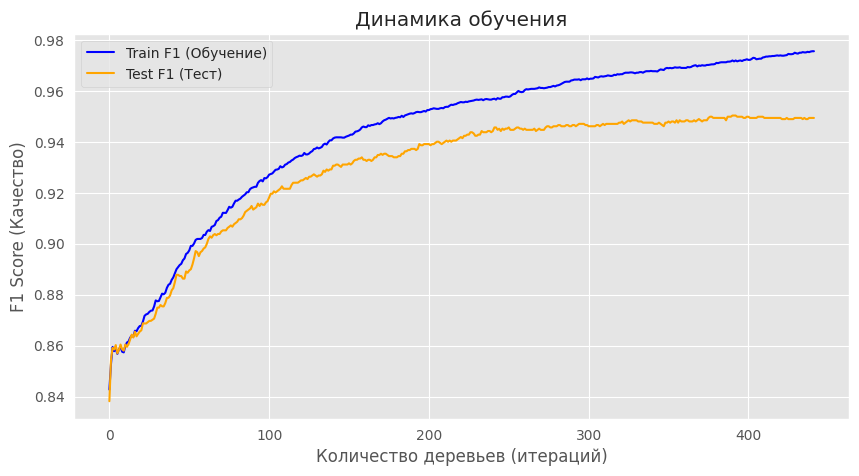

In [ ]:
# проверка на переобучение

y_train_pred = model_cb.predict(X_train_cb)
y_test_pred  = model_cb.predict(X_test_cb)

#  Выводы
print("Train")
print(classification_report(y_train_cb, y_train_pred))

print("\nTest")
print(classification_report(y_test_cb, y_test_pred))

# График обучения
evals = model_cb.get_evals_result()

plt.figure(figsize=(10, 5))
plt.plot(evals['learn']['TotalF1'], label='Train F1 (Обучение)', color='blue')
plt.plot(evals['validation']['TotalF1'], label='Test F1 (Тест)', color='orange')
plt.title('Динамика обучения')
plt.xlabel('Количество деревьев (итераций)')
plt.ylabel('F1 Score (Качество)')
plt.legend()
plt.grid(True)
plt.show()

Результаты обучения модели CatBoost демонстрируют высокое качество и хорошую обобщающую способность:

Высокая точность: Итоговая метрика на тестовой выборке (95.03%) подтверждает, что модель успешно научилась распознавать сложные поведенческие паттерны, заложенные на этапе кластеризации

Отсутствие переобучения: Разрыв между точностью на обучающей (97.2%) и тестовой (95.0%) выборках минимален. Это означает, что модель не просто зазубрила тренировочные данные, а выявила реальные логические закономерности

Эффективность алгоритма: Детектор переобучения остановил процесс на 392 итерации, выбрав оптимальную точку. Модель достигла пика качества довольно быстро, что говорит о высокой информативности подготовленных признаков (Feature Engineering)

Вывод: Разработанный классификатор является надежным инструментом. Он позволяет с точностью ~95% мгновенно определять сегмент клиента, которого он видит впервые, что делает систему полностью готовой к внедрению в реальный бизнес-процесс


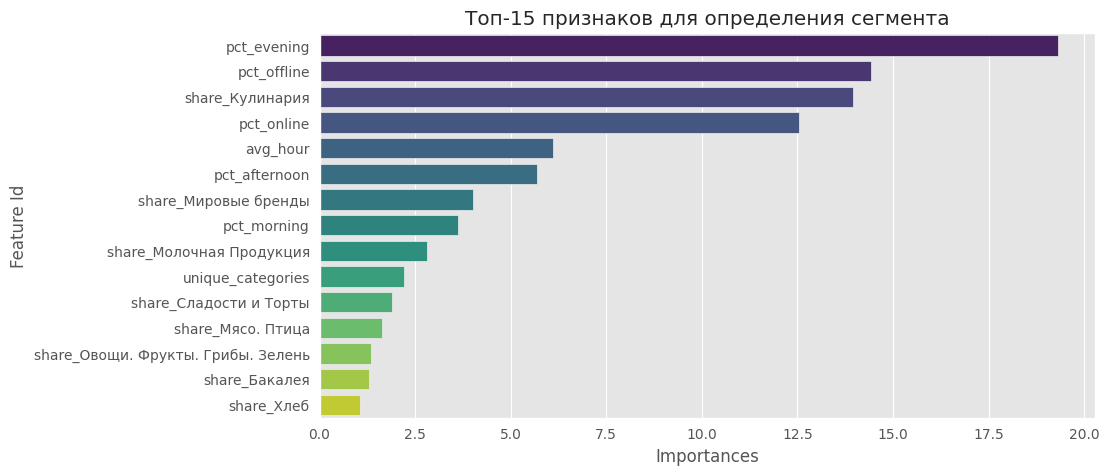

In [ ]:
# Важность признаков
feat_importances = model_cb.get_feature_importance(prettified=True)
plt.figure(figsize=(10, 5))
sns.barplot(x='Importances', y='Feature Id', data=feat_importances.head(15), palette='viridis')
plt.title('Топ-15 признаков для определения сегмента')
plt.show()

##Анализ смешанных сегментов

In [ ]:
# Анализ клиентов
cluster_names = {
    0: 'Холостяки (Офлайн)',
    1: 'VIP / Семья (Премиум)',
    2: 'Эконом / Базовый' ,
    3: 'Офисники (Ланчи)'
}

df_all = df_full_labeled.copy()

cols_drop_all = [
    'user_id', 'cluster', 'cluster_8', 'segment', 'sub_cluster',
    'x', 'y', 'x_8', 'y_8', 'is_outlier'
]
X_all = df_all.drop(columns=cols_drop_all, errors='ignore')

all_probs = model_cb.predict_proba(X_all)
#достаем главный кластер
final_scoring = pd.DataFrame(all_probs, columns=[f'prob_{i}' for i in range(4)], index=df_all.index)
final_scoring['user_id'] = df_all['user_id']
final_scoring['main_cluster'] = model_cb.predict(X_all)

# ищем второй кластер
top2_idx = np.argsort(-all_probs, axis=1)[:, :2]
top2_probs = -np.sort(-all_probs, axis=1)[:, :2]

final_scoring['second_cluster'] = top2_idx[:, 1]
final_scoring['second_prob'] = top2_probs[:, 1]
final_scoring['main_prob'] = top2_probs[:, 0]

# порог >25% для второстепенного кластера
threshold = 0.25
mixed_users = final_scoring[final_scoring['second_prob'] > threshold].copy()

# выводы
print(f"Всего клиентов: {len(final_scoring)}")
print(f"Смешанных (>{threshold*100:.0f}%): {len(mixed_users)} ({len(mixed_users)/len(final_scoring):.1%})")

cross_stats = mixed_users.groupby(['main_cluster', 'second_cluster']).size().reset_index(name='count')
cross_stats = cross_stats.sort_values('count', ascending=False).head(5)

print("топ-5 пересечений:")
for _, row in cross_stats.iterrows():
    c1 = int(row['main_cluster'])
    c2 = int(row['second_cluster'])
    name1 = cluster_names.get(c1, str(c1))
    name2 = cluster_names.get(c2, str(c2))
    print(f" {name1} -> {name2}: {row['count']} чел.")

print("Примеры (кому рассылать предложения):")
for i in range(min(3, len(mixed_users))):
    u = mixed_users.iloc[i]
    c1 = int(u['main_cluster'])
    c2 = int(u['second_cluster'])
    name1 = cluster_names.get(c1, str(c1))
    name2 = cluster_names.get(c2, str(c2))

    print(f"ID {int(u['user_id'])}:")
    print(f"   Сейчас: {name1} ({u['main_prob']:.0%})")
    print(f"   Похож на: {name2} ({u['second_prob']:.0%})")

Всего клиентов: 10688
Смешанных (>25%): 1104 (10.3%)
топ-5 пересечений:
 VIP / Семья (Премиум) -> Офисники (Ланчи): 141 чел.
 Холостяки (Офлайн) -> Эконом / Базовый: 139 чел.
 Эконом / Базовый -> Холостяки (Офлайн): 137 чел.
 Офисники (Ланчи) -> VIP / Семья (Премиум): 136 чел.
 VIP / Семья (Премиум) -> Холостяки (Офлайн): 108 чел.
Примеры (кому рассылать предложения):
ID 7302:
   Сейчас: Холостяки (Офлайн) (73%)
   Похож на: Офисники (Ланчи) (25%)
ID 1994:
   Сейчас: Холостяки (Офлайн) (54%)
   Похож на: VIP / Семья (Премиум) (46%)
ID 375:
   Сейчас: VIP / Семья (Премиум) (61%)
   Похож на: Офисники (Ланчи) (38%)


Описание сегментов

Кластер 0: Вечерний спрос (Холостяки)
Это клиенты, которые посещают магазин преимущественно офлайн в районе 17:00–18:00. В их чеке преобладает готовая еда (кулинария), замороженные полуфабрикаты и сладости. Средний чек составляет около 1100 рублей. Поведенческий паттерн указывает на покупку быстрого ужина после работы

Кластер 1:
Премиум и Семьи (VIP)
Самый доходный сегмент. Характеризуется самым высоким средним чеком (более 1700 рублей) и самой высокой частотой покупок. В корзине широкий ассортимент: свежие овощи, фрукты, мясо, а также товары мировых брендов. Покупают много и впрок, часто используют доставку

Кластер 2:
 Эконом (Базовый)
Клиенты с самым низким средним чеком (менее 1000 рублей). Корзина состоит из товаров первой необходимости: хлеб, молочная продукция, бакалея. Доля импульсивных покупок и дорогих товаров минимальна. Покупки совершаются преимущественно офлайн

Кластер 3: Офисные сотрудники (Ланчи)
Группа с высокой долей онлайн-заказов (более 60%). Пик активности приходится на обеденное время (12:00). Основу корзины (52%) составляет кулинария. Сырые продукты (мясо, овощи) практически отсутствуют. Это заказы готовых обедов в офис или домой


Порог в 25% для вторичного кластера был выбран эмпирически для фильтрации случайностей в поведении. Это позволило выделить 10.3% целевой аудитории с наиболее выраженным смешанным профилем потребления, что является хорошей базой для проведения точечных маркетинговых кампаний

##Экономика

In [ ]:

# Экономический расчет (uplift)
import numpy as np
import pandas as pd

# маржа
MARGE = 0.25

marketing_params = {
    0: {'uplift': 0.05, 'cost': 5},
    1: {'uplift': 0.10, 'cost': 5},
    2: {'uplift': 0.03, 'cost': 5},
    3: {'uplift': 0.07, 'cost': 5}
}

results = X_test_cb.copy()
results['Pred_Cluster'] = model_cb.predict(X_test_cb)

if 'total_spent' in df_test.columns:
  results['total_spent'] = df_test['total_spent']

def calc_profit(row):
    clust = row['Pred_Cluster']
    if isinstance(clust, (list, np.ndarray)): clust = clust[0]
    clust = int(clust)

    spent = row['total_spent']
    params = marketing_params.get(clust, {'uplift': 0, 'cost': 0})

    rev_uplift = spent * params['uplift']
    net_profit = (rev_uplift * MARGE) - params['cost']
    return net_profit

results['Net_Profit_Uplift'] = results.apply(calc_profit, axis=1)

# выводы
total_profit = results['Net_Profit_Uplift'].sum()
avg_profit = results['Net_Profit_Uplift'].mean()

# Для прогноза на всю базу умножаем среднее на размер всей базы
total_base_size = len(X_train_cb) + len(X_test_cb)
total_proj = avg_profit * total_base_size

print(f"Прибыль на тесте ({len(results)} чел): {total_profit:,.0f} руб.")
print(f"Средняя прибыль с клиента: {avg_profit:.1f} руб.")
print(f"Прогноз на всю базу ({total_base_size} чел): {total_proj:,.0f} руб.")

Прибыль на тесте (2138 чел): 3,574,845 руб.
Средняя прибыль с клиента: 1672.1 руб.
Прогноз на всю базу (10690 чел): 17,874,223 руб.


Внедрение системы персонализированных предложений на основе сегментации способно принести 17,9 млн рублей дополнительной чистой прибыли в год на базу в 10 тыс. человек (при марже 25%, стоимости сообщения 5 руб и конверсии 3-10 для кластеров). Это подтверждает высокую экономическую эффективность проекта и быструю окупаемость затрат на разработку

##Streamlit

In [ ]:
import joblib
joblib.dump(model_cb, 'model_cb.pkl')

['model_cb.pkl']

In [ ]:
X_train_cb.columns

Index(['num_checks', 'total_spent', 'days_since_last', 'avg_check', 'avg_hour',
       'pct_afternoon', 'pct_evening', 'pct_morning', 'pct_night',
       'pct_offline', 'pct_online', 'unique_categories', 'share_Алкоголь',
       'share_Бакалея', 'share_Дача Сад Огород', 'share_Детское',
       'share_Замороженные п/ф', 'share_Индилавка', 'share_Консервация',
       'share_Кулинария', 'share_Микромаркет', 'share_Мировые бренды',
       'share_Молочная Продукция', 'share_Мороженое',
       'share_Мясные деликатесы. Колбасы', 'share_Мясо. Птица',
       'share_Напитки', 'share_Нон-Фуд', 'share_Овощи. Фрукты. Грибы. Зелень',
       'share_Партнерские товары', 'share_Пекарня', 'share_Проекты нон-фуд',
       'share_Рационы', 'share_Рыба. Морепродукты', 'share_Сладости и Торты',
       'share_Сухофрукты. Сушеные грибы, ягоды. Орехи', 'share_Сыры',
       'share_Хлеб'],
      dtype='object')

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 52.1 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.0
    Uninstalling cachetools-7.0.0:
      Successfully uninstalled cachetools-7.0.0


In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
import numpy as np


try:
    model = joblib.load("model_cb.pkl")
except:
    st.error("Ошибка")
    st.stop()

# интерфейс
st.title("Сегментация клиентов торговой сети")
st.write("Введите данные о клиенте:")

col1, col2 = st.columns(2)

with col1:
    total_spent = st.number_input("Общие траты за год (руб)", 0, 1000000, 50000)
    frequency = st.number_input("Количество покупок", 1, 500, 20)
    avg_receipt = st.number_input("Средний чек", 100, 20000, 1500)

with col2:
    online_share = st.slider("Доля Онлайн-заказов", 0.0, 1.0, 0.2)
    culinary_share = st.slider("Доля Кулинарии", 0.0, 1.0, 0.1)
    hour = st.slider("Любимый час покупки", 0, 23, 18)

if st.button('Определить профиль клиента'):
    # Получаем имена фичей из модели
    feature_names = model.feature_names_

    # Создаем строку с нулями
    data = pd.DataFrame(np.zeros((1, len(feature_names))), columns=feature_names)


    if 'total_spent' in data.columns: data['total_spent'] = total_spent
    if 'frequency' in data.columns: data['frequency'] = frequency
    if 'avg_receipt' in data.columns: data['avg_receipt'] = avg_receipt
    if 'hour_mode' in data.columns: data['hour_mode'] = hour

    for col in data.columns:
        if 'Кулинария' in col:
            data[col] = culinary_share * total_spent


    prediction = int(model.predict(data)[0])
    probs = model.predict_proba(data)[0]

    names = {
        0: "Холостяки (Ужин)",
        1: "VIP / Семья",
        2: "Эконом" ,
        3: "Офисники (Ланч)"
    }

    st.success(f"Результат: {names.get(prediction, prediction)}")
    st.write(f"Уверенность: {probs[prediction]:.1%}")
    st.bar_chart(probs)

Overwriting app.py


In [ ]:
!npm install -g localtunnel
!streamlit run app.py & npx localtunnel --port 8501 & curl ipv4.icanhazip.com

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
changed 22 packages in 3s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏35.187.152.235
⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.187.152.235:8501

your url is: https://green-crews-smoke.loca.lt
/content/app.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prediction = int(model.predict(data)[0])
  Stopping...


##Дальнейшее развитие проекта (Roadmap)
Текущее решение является полноценным MVP. В следующих итерациях я планирую  развитие по 4 направлениям:

1. Анализ стабильности сегментов

Необходимо изучить «миграцию» клиентов между кластерами на длинном горизонте времени. Это позволит понять, как часто меняется лайфстайл покупателя (например, переход из студентов в семейный сегмент) и вовремя адаптировать маркетинговую стратегию (расчет матрицы переходов, чтобы увидеть, как клиенты мигрируют между группами месяц к месяцу)

2. Использование временных рядов

Для более точного прогноза планируется добавить динамические признаки (изменение среднего чека, частоты покупок и состава корзины во времени). Это поможет модели ловить тренды в поведении клиента еще до того, как он окончательно сменит сегмент.
Так же, ри переходе к анализу динамики поведения обязательным этапом станет внедрение time series split (вместо случайного разбиения). Это позволит валидировать модель на будущих периодах относительно прошлых, исключая риск заглядывания в будущее и делая оценку точности максимально приближенной к реальности

3. Определение минимального порога данных

Рассчитать, после какой по счету покупки вероятность предсказания кластера становится стабильной. Это позволит максимально рано (например, уже после 3-й покупки) включать персонализированный маркетинг и не тратить лишний бюджет на «холодные» рассылки (например, проведение ретроспективного теста: замер метрики Precision/Recall модели на разном количестве транзакций (1-я, 3-я, 5-я покупка). Цель - найти точку насыщения признаков, после которой предсказание кластера становится стабильным)

4. Внедрение рекомендательной системы

В дополнение к сегментации планируется реализовать два уровня товарных рекомендаций:

Циклические покупки: прогноз потребности в товарах регулярного спроса (порошки, корма) на основе индивидуальных интервалов потребления (расчет среднего интервала между покупками и реализация триггерных рассылок)

Сопутствующие товары: использование алгоритмов ассоциативных правил для предложения комплементарных товаров внутри чека (например, предложение соуса к пельменям) (например, применение алгоритмов FP-Growth или Apriori ( mlxtend) для поиска ассоциативных правил внутри чека и формирования персонализированных корзин
